# The Metal Corpus
### A Linguistic Analysis of Heavy Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup

In [39]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('/Users/williamanderson/VisualStudio/metal_lyrics87.db')

subgenres = ['traditional', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Unique words: {len(df_words):,}")
print(f"Artists: {len(df_artists):,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

Unique words: 89,942
Artists: 539
Releases: 5,151
Songs: 39,116


---

## Dataset Overview

### Word Count by Subgenre

Note: raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Traditional and thrash metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

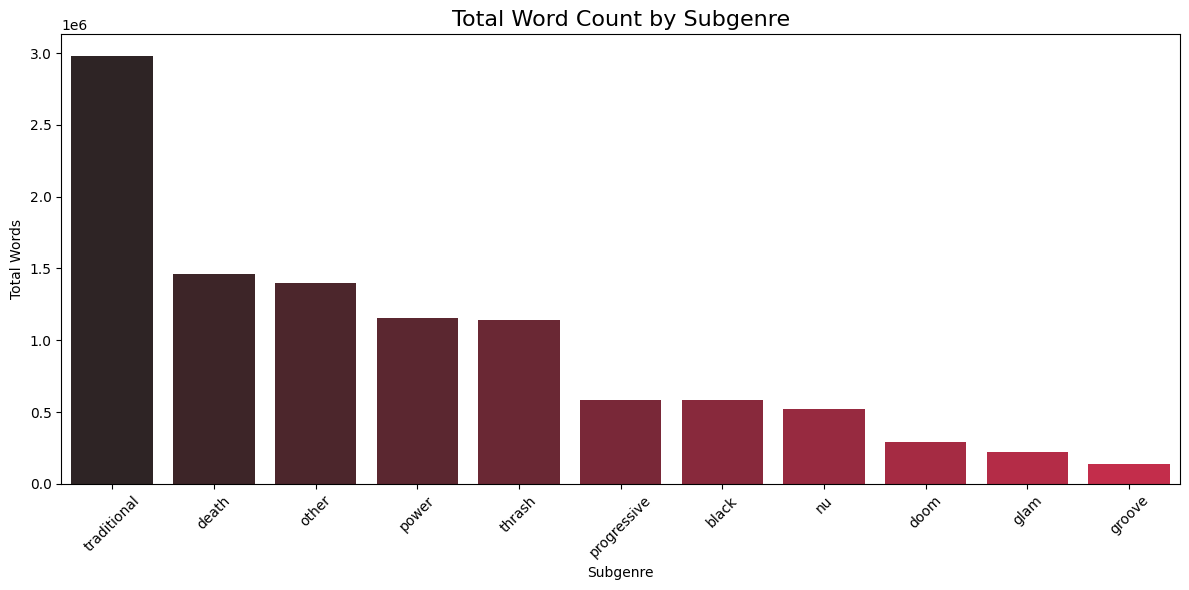

   subgenre  total_words
traditional      2981590
      death      1458421
      other      1401214
      power      1154836
     thrash      1140314
progressive       584714
      black       582440
         nu       524490
       doom       288495
       glam       220664
     groove       139665


In [52]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.ylabel('Total Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(totals_df.to_string(index=False))

---

###  Country Representation

This dataset includes lyrics of bands from 45 countries. The United States leads by a significant margin, showing both the country's outsized influence on metal's development and the sheer size of its music scene. The next highest-represented countries are the UK, Sweden, and Germany, three countries whose influence on heavy metal is disproportionate to their size. This sets up an interesting per-capita question explored later in the findings.

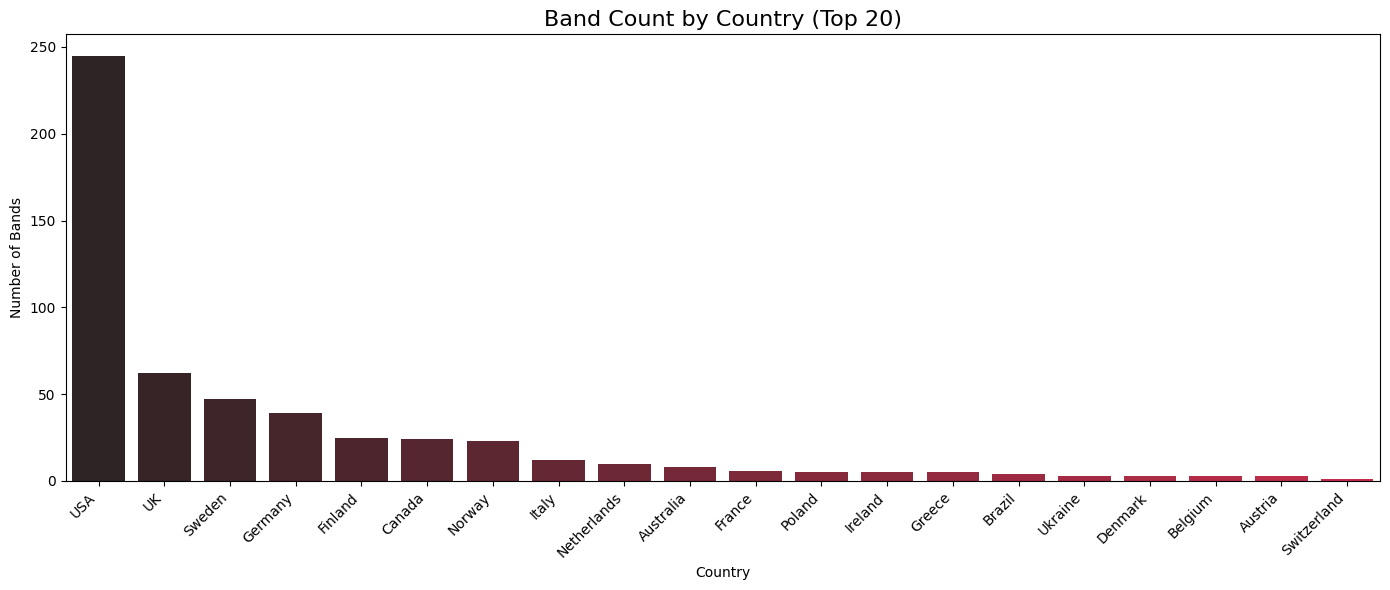

    country  band_count
        USA         245
         UK          62
     Sweden          47
    Germany          39
    Finland          25
     Canada          24
     Norway          23
      Italy          12
Netherlands          10
  Australia           8
     France           6
     Poland           5
    Ireland           5
     Greece           5
     Brazil           4
    Ukraine           3
    Denmark           3
    Belgium           3
    Austria           3
Switzerland           1


In [50]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', hue='country', palette='dark:crimson', legend=False)
plt.title('Band Count by Country (Top 20)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Bands')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))

---

### Number of Songs by Subgenre

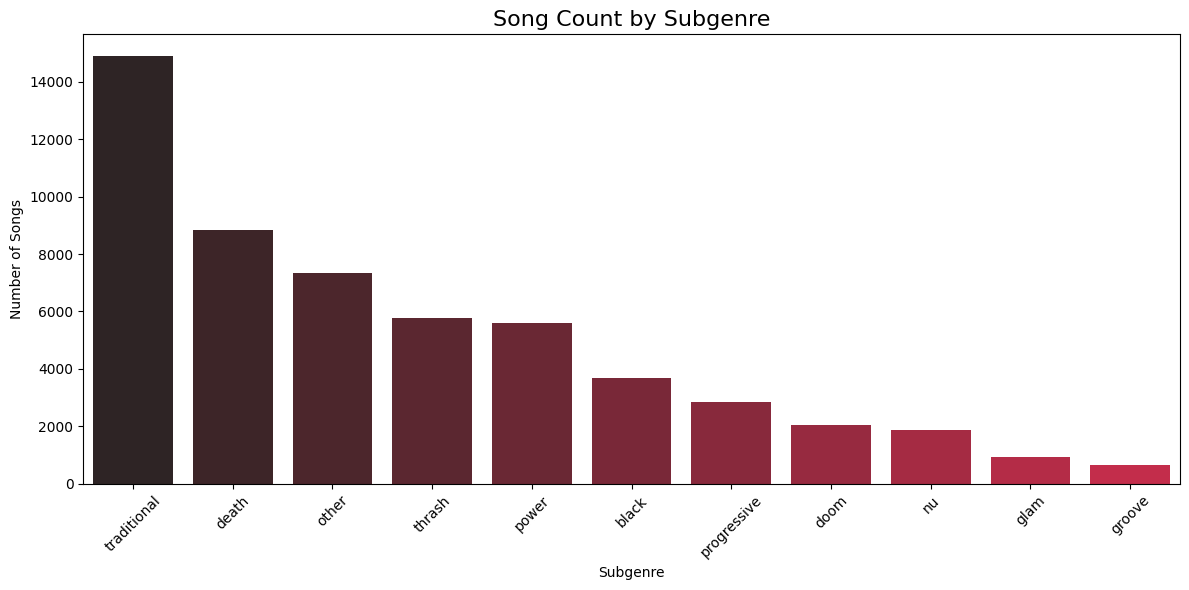

   subgenre  song_count
traditional       14905
      death        8852
      other        7329
     thrash        5778
      power        5601
      black        3695
progressive        2851
       doom        2062
         nu        1875
       glam         927
     groove         662


In [49]:
style_to_subgenre = {
    "heavy metal": "traditional",
    "speed metal": "traditional",
    "traditional": "traditional",
    "doom metal": "doom",
    "funeral doom metal": "doom",
    "doom": "doom",
    "thrash": "thrash",
    "crossover thrash": "thrash",
    "speedcore": "thrash",
    "death metal": "death",
    "death": "death",
    "technical death metal": "death",
    "brutal death metal": "death",
    "melodic death metal": "death",
    "deathcore": "death",
    "black metal": "black",
    "atmospheric black metal": "black",
    "black": "black",
    "blackgaze": "black",
    "groove metal": "groove",
    "groove": "groove",
    "progressive metal": "progressive",
    "progressive": "progressive",
    "prog": "progressive",
    "power metal": "power",
    "power": "power",
    "symphonic metal": "power",
    "glam metal": "glam",
    "glam": "glam",
    "hair metal": "glam",
    "nu metal": "nu",
    "nu": "nu",
    "other": "other",
    "funk metal": "other",
    "metalcore": "other",
    "alt metal": "other",
    "alternative metal": "other",
    "post-metal": "other",
    "gothic metal": "other",
    "folk metal": "other",
    "sludge metal": "other",
    "viking metal": "other",
    "industrial metal": "other",
    "grindcore": "other",
    "goregrind": "other",
} #mapping the subgenres used in Discogs to my conventions

df_release_subgenres = pd.read_sql("""
    SELECT rs.subgenre_name as raw_subgenre, COUNT(DISTINCT s.id) as song_count
    FROM songs s
    JOIN releases r ON s.release_id = r.id
    JOIN release_subgenres rs ON r.id = rs.release_id
    GROUP BY rs.subgenre_name
""", conn)

# Map raw subgenre names to our standard ones
df_release_subgenres['subgenre'] = df_release_subgenres['raw_subgenre'].str.lower().map(style_to_subgenre)
df_release_subgenres = df_release_subgenres.dropna(subset=['subgenre'])

# Group by mapped subgenre and sum
df_songs_by_subgenre = df_release_subgenres.groupby('subgenre')['song_count'].sum().reset_index()
df_songs_by_subgenre = df_songs_by_subgenre.sort_values('song_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_songs_by_subgenre, x='subgenre', y='song_count', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Song Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_songs_by_subgenre.to_string(index=False))

---

### Release Year Distribution

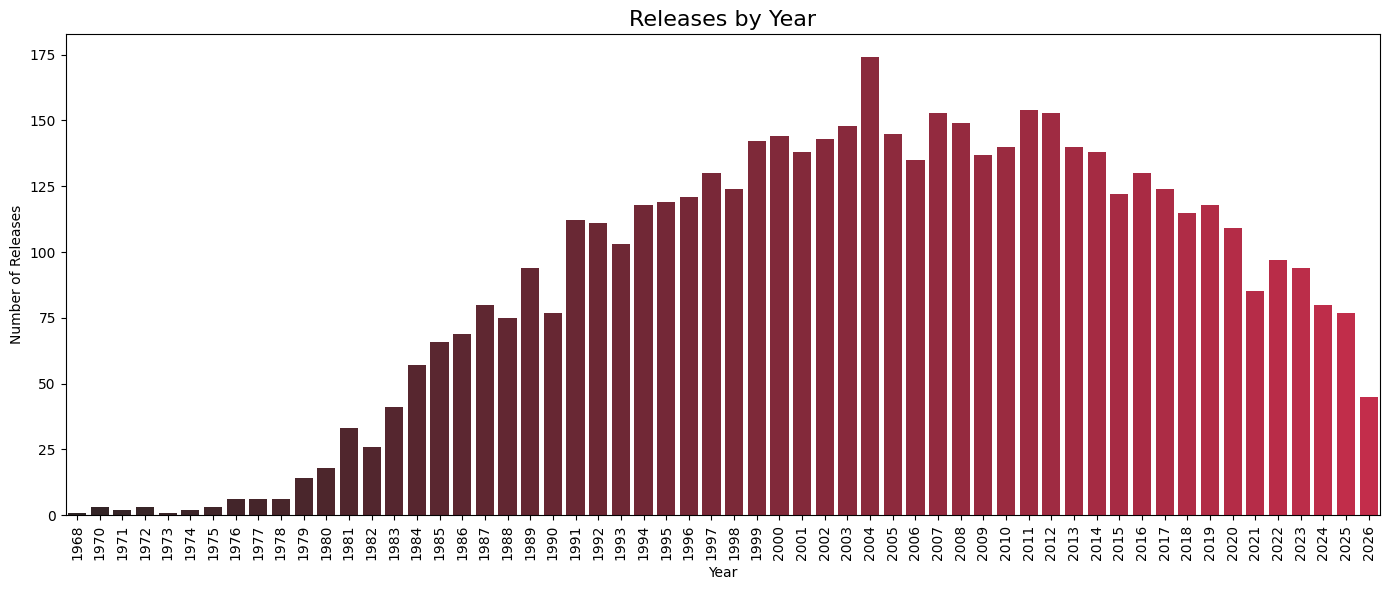

Earliest release: 1968
Most recent release: 2026
Most active year: 2004 (174 releases)


In [47]:
df_years = pd.read_sql("""
    SELECT year, COUNT(*) as release_count
    FROM releases
    WHERE year != 'Unknown'
    GROUP BY year
    ORDER BY year
""", conn)

df_years['year'] = pd.to_numeric(df_years['year'], errors='coerce')
df_years = df_years.dropna()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_years, x='year', y='release_count', hue='year', palette='dark:crimson', legend=False)
plt.title('Releases by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Earliest release: {int(df_years['year'].min())}")
print(f"Most recent release: {int(df_years['year'].max())}")
print(f"Most active year: {int(df_years.loc[df_years['release_count'].idxmax(), 'year'])} ({df_years['release_count'].max()} releases)")

---

### Vocalist Gender Breakdown

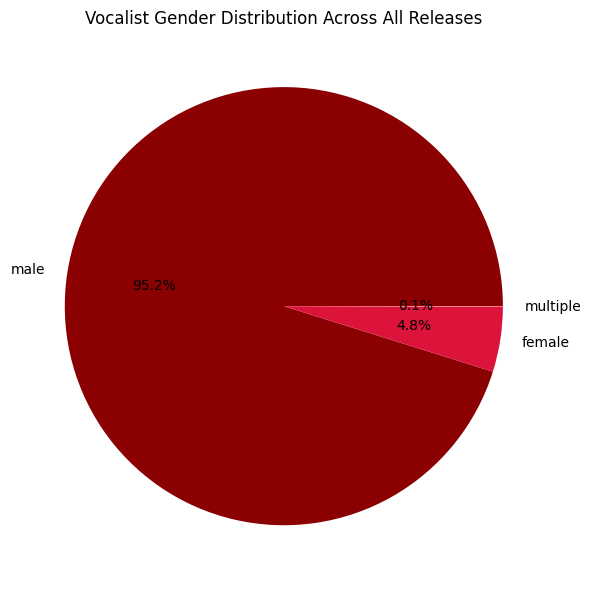

vocalist_gender  count
           male   4902
         female    246
       multiple      3


In [46]:
df_gender = pd.read_sql("""
    SELECT vocalist_gender, COUNT(*) as count
    FROM releases
    GROUP BY vocalist_gender
    ORDER BY count DESC
""", conn)

plt.figure(figsize=(8, 6))
plt.pie(df_gender['count'], labels=df_gender['vocalist_gender'], autopct='%1.1f%%', 
        colors=['#8B0000', '#DC143C', '#FF6B6B', '#FFB3B3'])
plt.title('Vocalist Gender Distribution Across All Releases', fontsize=12)
plt.tight_layout()
plt.show()

print(df_gender.to_string(index=False))